## __Phase 2: Data Preparation__

### __Import packages__

In [2]:
import pandas as pd
import numpy as np
from haversine import haversine
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
from scripts.data_pipeline.data_preprocessing.AIS.step01_filter_short_tracks import * 
from scripts.data_pipeline.data_preprocessing.AIS.step02_filter_speed_outliers import * 
from scripts.data_pipeline.data_preprocessing.AIS.step03_make_continuous_tracks import * 
from scripts.data_pipeline.data_preprocessing.AIS.step04_create_sample_data import * 
from scripts.visualization.map_vessel_routes_v2 import * 
from scripts.data_pipeline.data_matching.create_training_data import * 

### __Load 'cargo' data__

In [4]:
df_preprocessing = (
    pd.read_parquet("../data/processed/cargo_vessels.parquet")[["MMSI", "IMO", "BaseDateTime", "LAT", "LON", "SOG", "Heading"]]
    .sort_values(["MMSI", "BaseDateTime"])
    .reset_index(drop=True)
    .copy()
)
df_preprocessing.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading
0,8,None,2024-01-31 16:57:25,47.55391,-122.65412,0.0,511.0
1,205717000,IMO9748485,2024-01-01 02:42:35,46.89866,-125.72790,13.2,92.0
2,205717000,IMO9748485,2024-01-01 03:09:33,46.89496,-125.59250,13.6,95.0
3,205717000,IMO9748485,2024-01-01 03:10:44,46.89473,-125.58606,13.6,95.0
4,205717000,IMO9748485,2024-01-01 03:20:54,46.89337,-125.52966,13.8,93.0


### __Step 1: Filter out trajectories that contain less than 5 data points__

In [5]:
df_prep_step1 = remove_short_tracks(df_preprocessing, min_observations=5)
df_prep_step1.head(5)

80 tracks with ≤ 5 observations were removed


,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading
1,205717000,IMO9748485,2024-01-01 02:42:35,46.89866,-125.72790,13.2,92.0
2,205717000,IMO9748485,2024-01-01 03:09:33,46.89496,-125.59250,13.6,95.0
3,205717000,IMO9748485,2024-01-01 03:10:44,46.89473,-125.58606,13.6,95.0
4,205717000,IMO9748485,2024-01-01 03:20:54,46.89337,-125.52966,13.8,93.0
5,205717000,IMO9748485,2024-01-01 03:23:14,46.89343,-125.51669,13.7,93.0


### __Step 2: Filtering unrealistic vessel speeds__

AIS data was filtered to exclude extreme and unlikely speeds. This includes removing vessels that were either nearly stationary or moving at technically implausible speeds.


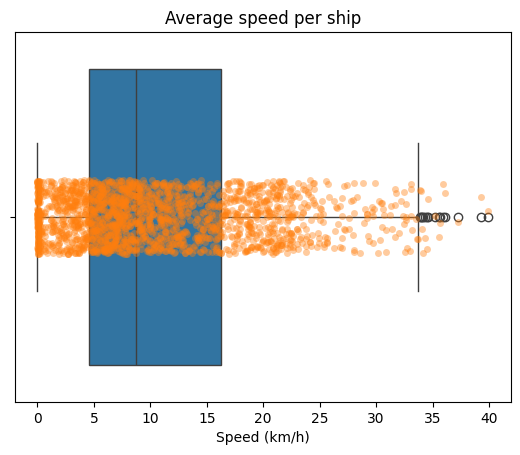

In [6]:
# Remove high-speed outliers (unrealistically fast vessels, as observed during data exploration (phase 1))
df_prep_step2 = df_prep_step1.copy()
df_speed = add_speed_info(df_prep_step2)

df_prep_step2 = remove_high_speed_outliers(df_speed)
avg_speeds_boxplot_1 = df_prep_step2.groupby("MMSI")["speed_kph"].mean().reset_index()

sns.boxplot(data=avg_speeds_boxplot_1, x="speed_kph")
sns.stripplot(data=avg_speeds_boxplot_1, x="speed_kph", alpha=0.4, jitter=True)
plt.title("Average speed per ship")
plt.xlabel("Speed (km/h)")
plt.show()

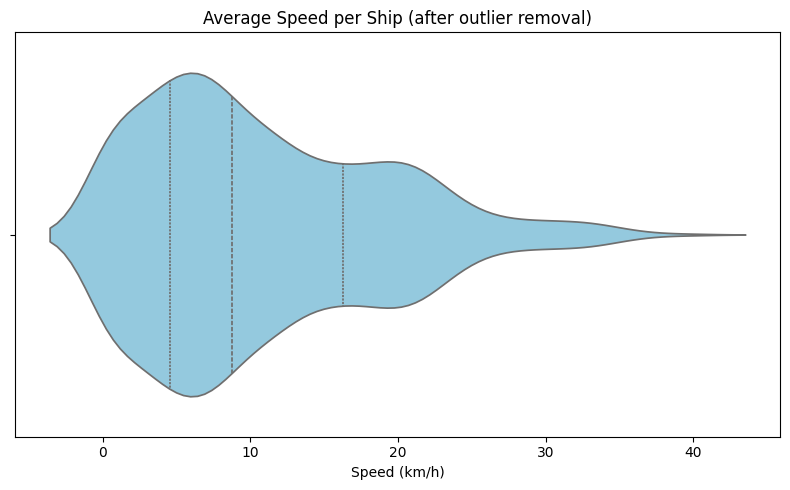

In [7]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=avg_speeds_boxplot_1, x="speed_kph", inner="quartile", color='skyblue')

plt.title("Average Speed per Ship (after outlier removal)")
plt.xlabel("Speed (km/h)")
plt.tight_layout()
plt.show()

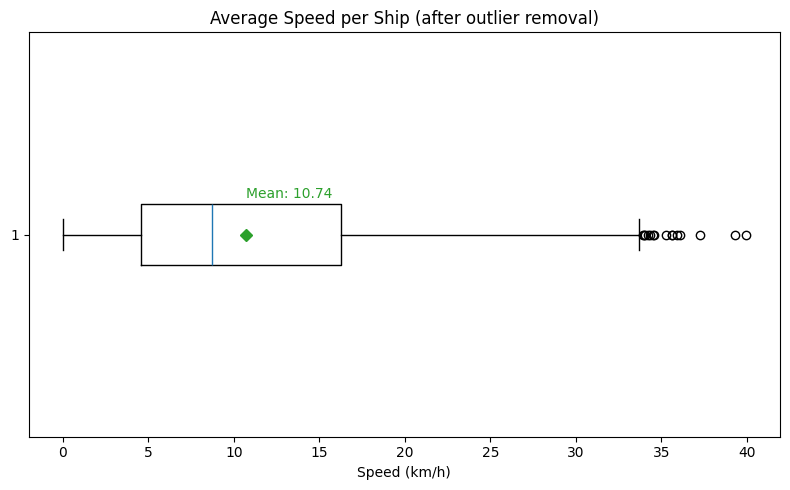

In [8]:
data = avg_speeds_boxplot_1["speed_kph"]
mean_speed = data.mean()

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    data,
    vert=False,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='tab:green', markeredgecolor='tab:green')
)

for median in box['medians']:
    median.set_color('tab:blue')

ax.text(mean_speed, 1.1, f"Mean: {mean_speed:.2f}", color='tab:green', ha='left', va='center')

ax.set_title("Average Speed per Ship (after outlier removal)")
ax.set_xlabel("Speed (km/h)")
plt.tight_layout()
plt.show()

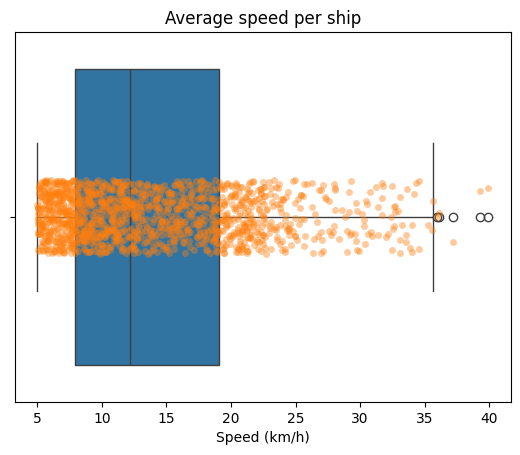

In [9]:
# Remove tracks with average speed below threshold (defaults is set to 5 km/h)
df_prep_step2 = remove_low_speed_outliers(df_prep_step2)
avg_speeds_boxplot_2 = df_prep_step2.groupby("MMSI")["speed_kph"].mean().reset_index()

sns.boxplot(data=avg_speeds_boxplot_2, x="speed_kph")
sns.stripplot(data=avg_speeds_boxplot_2, x="speed_kph", alpha=0.4, jitter=True)
plt.title("Average speed per ship")
plt.xlabel("Speed (km/h)")
plt.show()

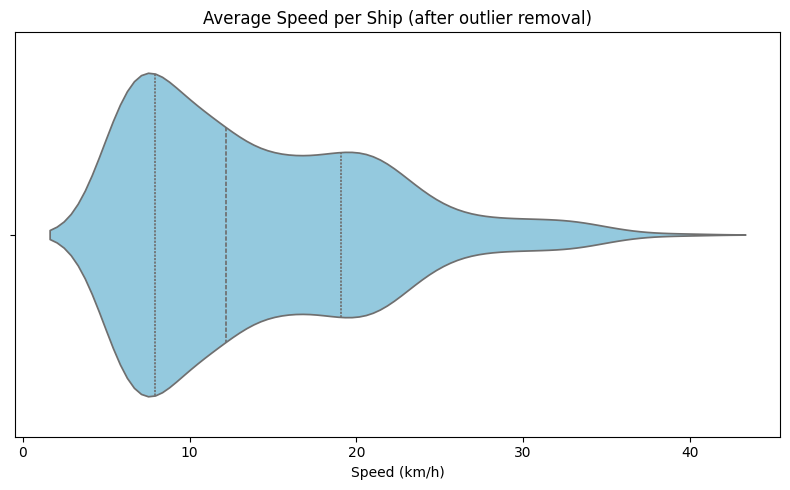

In [10]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=avg_speeds_boxplot_2, x="speed_kph", inner="quartile", color='skyblue')

plt.title("Average Speed per Ship (after outlier removal)")
plt.xlabel("Speed (km/h)")
plt.tight_layout()
plt.show()

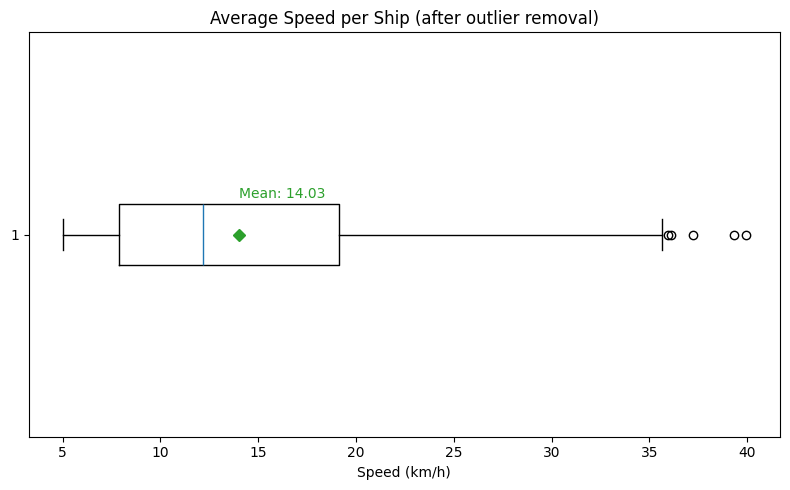

In [11]:
data = avg_speeds_boxplot_2["speed_kph"]
mean_speed = data.mean()

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    data,
    vert=False,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='tab:green', markeredgecolor='tab:green')
)

for median in box['medians']:
    median.set_color('tab:blue')

ax.text(mean_speed, 1.1, f"Mean: {mean_speed:.2f}", color='tab:green', ha='left', va='center')

ax.set_title("Average Speed per Ship (after outlier removal)")
ax.set_xlabel("Speed (km/h)")
plt.tight_layout()
plt.show()

### __Step 3: Handeling incomplete vessel tracks__

Some ships transmitted AIS signals only intermittently, leading to large time gaps between observations. A new trajectory (subroute) was initiated whenever the time gap exceeded the 99th percentile (~6 minutes)

In [12]:
df_prep_step3 = df_prep_step2.copy()
df_prep_step3 = split_into_continuous_tracks(df_prep_step3)
df_prep_step3.head(5)

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


In [13]:
# 'Normal' track
plot_AIS_route(df_preprocessing, 636021579)

In [14]:
# Track splitted into more continuous trajectories
plot_AIS_subroutes(df_prep_step3, 636021579)

### __Step 4: Sampling a representative set of routes from the AIS population__

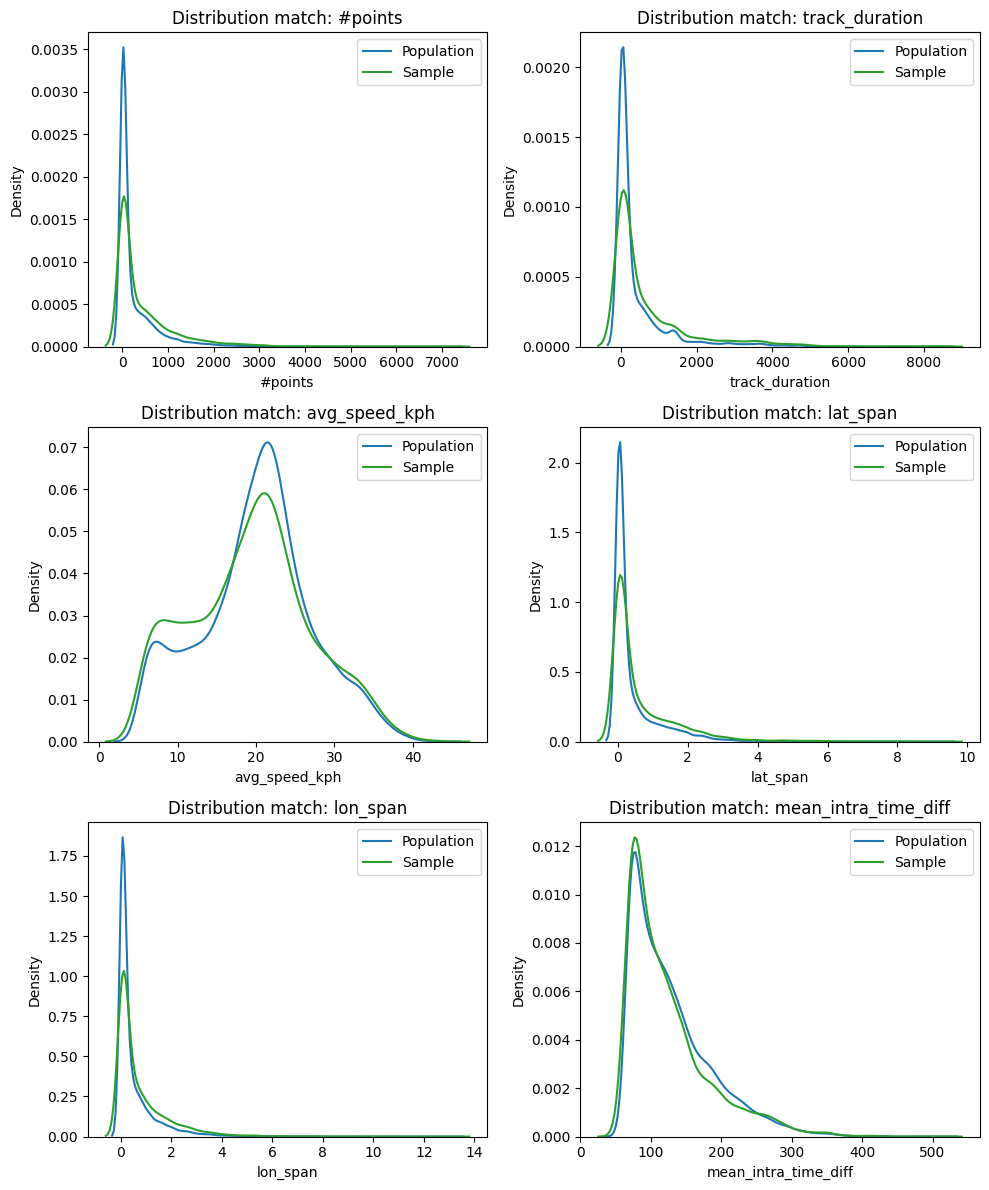

In [19]:
# Data
sampled_tracks, AIS_charateristics, columns, df_subset = sample_representative_routes(df_prep_step3)

# Subplot layout
n_cols = 2  # number of columns per row 
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  

# Plot columns
for idx, col in enumerate(columns):
    ax = axes[idx]
    sns.kdeplot(AIS_charateristics[col], label="Population", ax=ax)
    sns.kdeplot(sampled_tracks[col], label="Sample", color="tab:green", ax=ax)
    ax.set_title(f"Distribution match: {col}")
    ax.legend()

for i in range(len(columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### __Create training data, inculding the generation of synthethic RF signals__

In [16]:
df_train_set, list_distance_diffs = generate_training_data(df_subset)

print("Max value:", max(list_distance_diffs))
df_train_set.head(5)

# Save files
# df_train_set.to_pickle("../scripts/test_scripts/train_data_sample_5000.pkl") 
# sampled_tracks.to_pickle("../scripts/test_scripts/statistics_sample_5000.pkl")  
# df_subset.to_pickle("../scripts/test_scripts/AIS_sample_no_RF_5000.pkl")

Max value: 2.380675025323449


,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,"(205717000, 3)",3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,"(205717000, 3)",3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,"(205717000, 3)",3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,"(205717000, 3)",3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,"(205717000, 3)",3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS


In [25]:
df_train_set.iloc[65:70]

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
68,"(205717000, 3)",3,205717000,2024-01-01 05:04:40,2024-01-01 05:04:40,NaT,"[46.89417, -124.94859]",None,AIS
69,"(205717000, 3)",3,205717000,2024-01-01 05:05:47,2024-01-01 05:05:47,NaT,"[46.89417, -124.94261]",None,AIS
70,"(205717000, 3)",3,205717000,2024-01-01 05:06:58,2024-01-01 05:06:58,NaT,"[46.89411, -124.93576]",None,AIS
71,"(205717000, 3)",3,205717000,2024-01-01 05:08:11,2024-01-01 05:08:11,NaT,"[46.89406, -124.92904]",None,AIS
0,"(205717000, 3)",3,205717000,2024-01-01 05:08:47,NaT,2024-01-01 05:08:47,None,"[46.905132569730185, -124.90139157632149]",RF


### __Plot AIS data and RF signals__

In [17]:
plot_AIS_and_RF_data(df_subset, df_train_set, [(636021579, 0)])

In [33]:
df_train_set

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,"(205717000, 3)",3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,"(205717000, 3)",3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,"(205717000, 3)",3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,"(205717000, 3)",3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,"(205717000, 3)",3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS
...,...,...,...,...,...,...,...,...,...
2189886,"(750000045, 16)",16,750000045,2024-01-10 22:58:19,2024-01-10 22:58:19,NaT,"[16.45501, -66.4437]",None,AIS
2189887,"(750000045, 16)",16,750000045,2024-01-10 23:02:55,2024-01-10 23:02:55,NaT,"[16.44986, -66.4364]",None,AIS
2189888,"(750000045, 16)",16,750000045,2024-01-10 23:04:12,2024-01-10 23:04:12,NaT,"[16.44836, -66.43436]",None,AIS
2189879,"(750000045, 16)",16,750000045,2024-01-10 23:08:37,NaT,2024-01-10 23:08:37,None,"[16.43139716169542, -66.44067859128745]",RF


In [34]:
sequence = df_train_set[df_train_set['ID'] == (205717000, 3)]

AIS_sequence = [(time, coord) for time, coord in zip(sequence["AIS_Timestamp"], sequence["AIS"]) 
                if pd.notna(time) and coord is not None]

RF_sequence = [(time, coord) for time, coord in zip(sequence["RF_Timestamp"], sequence["RF"]) 
               if pd.notna(time) and coord is not None]

In [41]:
len(AIS_sequence)

378

In [42]:
AIS_sequence

[(Timestamp('2024-01-01 03:40:24'), [46.89339, -125.42151]),
 (Timestamp('2024-01-01 03:44:15'), [46.89344, -125.39996]),
 (Timestamp('2024-01-01 03:45:33'), [46.8935, -125.39274]),
 (Timestamp('2024-01-01 03:46:39'), [46.89348, -125.38572]),
 (Timestamp('2024-01-01 03:48:20'), [46.89355, -125.37695]),
 (Timestamp('2024-01-01 03:49:57'), [46.89368, -125.36773]),
 (Timestamp('2024-01-01 03:51:15'), [46.8937, -125.36]),
 (Timestamp('2024-01-01 03:52:25'), [46.89372, -125.35423]),
 (Timestamp('2024-01-01 03:53:45'), [46.89378, -125.34686]),
 (Timestamp('2024-01-01 03:55:25'), [46.8938, -125.33758]),
 (Timestamp('2024-01-01 03:56:27'), [46.89382, -125.33176]),
 (Timestamp('2024-01-01 04:00:15'), [46.89393, -125.30989]),
 (Timestamp('2024-01-01 04:02:33'), [46.89406, -125.29792]),
 (Timestamp('2024-01-01 04:04:15'), [46.89415, -125.28836]),
 (Timestamp('2024-01-01 04:05:33'), [46.89419, -125.28094]),
 (Timestamp('2024-01-01 04:07:15'), [46.89429, -125.27133]),
 (Timestamp('2024-01-01 04:08:

In [36]:
RF_sequence

[(Timestamp('2024-01-01 05:08:47'), [46.905132569730185, -124.90139157632149]),
 (Timestamp('2024-01-01 08:26:02'), [46.928140679836154, -124.13749162721079]),
 (Timestamp('2024-01-01 11:40:10'), [46.904036021256516, -124.11232821381113]),
 (Timestamp('2024-01-01 15:27:16'), [46.91037655705591, -124.09487022207654])]